In [7]:
import pandas as pd

In [8]:
df = shark_dataset = pd.read_excel("https://www.sharkattackfile.net/spreadsheets/GSAF5.xls")

In [9]:
shark_dataset.shape

(7087, 23)

In [10]:
shark_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7087 entries, 0 to 7086
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7087 non-null   object 
 1   Year            7085 non-null   float64
 2   Type            7069 non-null   object 
 3   Country         7037 non-null   object 
 4   State           6600 non-null   object 
 5   Location        6520 non-null   object 
 6   Activity        6504 non-null   object 
 7   Name            6869 non-null   object 
 8   Sex             6509 non-null   object 
 9   Age             4093 non-null   object 
 10  Injury          7051 non-null   object 
 11  Fatal Y/N       6526 non-null   object 
 12  Time            3560 non-null   object 
 13  Species         3956 non-null   object 
 14  Source          7067 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 
 17  href            6796 non-null   o

In [11]:
shark_dataset.dtypes

Date               object
Year              float64
Type               object
Country            object
State              object
Location           object
Activity           object
Name               object
Sex                object
Age                object
Injury             object
Fatal Y/N          object
Time               object
Species            object
Source             object
pdf                object
href formula       object
href               object
Case Number        object
Case Number.1      object
original order    float64
Unnamed: 21        object
Unnamed: 22        object
dtype: object

In [12]:
shark_dataset["Fatal Y/N"].nunique()

12

In [13]:
shark_dataset["Fatal Y/N"].unique()

array(['N', 'Y', 'F', 'M', nan, 'n', 'Nq', 'UNKNOWN', 2017, 'Y x 2', ' N',
       'N ', 'y'], dtype=object)

In [ ]:
# date: inconsisten formating
# year: should be an integer
# state: not relevant
# name: not relevant
# age: should be integer
# empty colums that should be deleted: pdf, href formula, href, case number, case numer.1, original order, unnamed: 21 and unnamed: 22 

In [14]:
def rename_columns(df):
    """
    function N°1:
    remove white spaces (strip) and replace them by "_"

    """
    df1 = df.copy()
    df1.rename(columns={col : col.strip() for col in df1.columns}, inplace = True)
    df1.rename(columns={col : col.replace(" ", "_").lower() for col in df1.columns}, inplace = True)
    return df1

def delete_columns(df):
    """
    Function N°2
    
    delete irrelivent columns
    input: dataframe
    output: dataframe
    """
    df1 = df.copy()
    cols_to_delete = ["pdf", "Location", 'href formula', 'href', 'Case Number', 'Case Number.1','original order', 'Unnamed: 21', 'Unnamed: 22', "Species ","Source", "Name"]
      
    df1.drop(cols_to_delete, axis = 1, inplace = True)
    
    return df1
    
def clean_fatal_col(df):
    """
    function N°3:
    replaces values with Y/N
    
    """
    df1 = df.copy()
    df1["Fatal Y/N"] = df1["Fatal Y/N"].apply(lambda x : "N" if (str(x).strip().lower()[0] == "n" and len(str(x).strip()) != 3) else ("Y" if str(x).strip().lower().startswith("y") else str(x).strip().lower()))
    
    return df1

def clean_age_col(df):
    """
    function N°4:
    
    """
    df1 = df.copy()
    mapping_age = {"Middle age": 40, "young": 25, "Elderly" : 60, "Teen": 15, "teen": 15, '"middle-age"': 40,'"young"': 15 }
    df1["Age"] = df1.Age.apply(lambda x : str(x).strip().strip("?").strip("!").strip("+").strip("'s").strip("&"))
    df1["Age"] = df1.Age.replace(mapping_age)
                         
    return df1

def drop_rows(df):
    df1 = df.copy()
    """
    """

def activity_col_anlaysis(df):
    df1 = df.copy()
    df1["activity_category"] = df1["Activity"].apply(
        lambda x: "Swimming" if "swim" in str(x).lower() else 
                    ("Surfing" if "surf" in str(x).lower() else
                         "Diving" if "diving" in str(x).lower() else "Other"
                    ))
                                                            
    return df1

def drop_rows(df):
    
    """
    This functions drops the irrelivant rows: 
    1: from column FATAL Y/N:
    "nan"=561, "unknown": 71, "f": 5, "m": 3, "2017": 1 ==>641/4953(N)+1493(Y) =10%
    
    """
    df1 = df.copy()
    df1 = df1[(df1["Fatal Y/N"] == "N") | (df1["Fatal Y/N"] == "Y")]

    return df1
    
def main_clean_function(df):
    """
    input: a copy of df: shark attacks
    
    groups all clean functions.

    output a cleaned df
    """
    df1 = df.copy()
    df1 = delete_columns(df1)
    df1 = clean_fatal_col(df1)
    df1 = clean_age_col(df1)
    df1 = activity_col_anlaysis(df1)
    df1 = drop_rows(df1)
    
    df1 = rename_columns(df1) #this function should be at the end of the execution list, as column names changed
    return df1 

def top_attack_countries(df):
    """
    Calculates the top countries with the highest nbr of attacke, together with the kind of attackes (Fatal/injury)
    input DF
    Output: Returns the top 5 countries with the highest number of shark attacks,
    

    """
    df1 = df.copy()

    top10_overall = df1.groupby(["country", "fatal_y/n"])["fatal_y/n"].count().groupby(level=0, group_keys=False).nlargest(5)
    return top10_overall



df1=main_clean_function(df)


In [15]:
display(df1.head())

,date,year,type,country,state,activity,sex,age,injury,fatal_y/n,time,activity_category
0,14/04,2026.0,UNprovoked,Maldives,Gaafu Alif Atoll,Swimming,M,,Leg strpped off flesh later amputated in hospital,N,?,Swimming
1,3rd April,2026.0,Unprovoked,Australia,South Australia,Surfing,M,16,Bite wound to R ankle,N,?,Surfing
2,26th March,2026.0,Unprovoked,Bahamas,Andros Island,Swimming,F,22,Severe injuries to R arm,N,1730hrs,Swimming
3,25th March,2026.0,Unprovoked,Australia,South Australia,Diving,M,,NaN,N,?,Diving
4,22nd-23rd March,2026.0,Unprovoked,Australia,NSW,Surfing,M,30,Graze injuries R leg and ankle,N,?,Surfing


In [16]:
df1.dtypes

date                  object
year                 float64
type                  object
country               object
state                 object
activity              object
sex                   object
age                   object
injury                object
fatal_y/n             object
time                  object
activity_category     object
dtype: object

In [17]:
df1["type"].unique()

array(['UNprovoked', 'Unprovoked', 'Provoked', 'Questionable',
       'unprovoked', ' Provoked', 'Watercraft', 'Sea Disaster', '?', nan,
       'Unverified', 'Invalid', 'Under investigation', 'Boat'],
      dtype=object)

In [18]:
df1["type"].value_counts()

type
Unprovoked             5159
Provoked                633
Watercraft              343
Sea Disaster            237
Invalid                  25
Questionable             22
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unverified                1
Under investigation       1
Name: count, dtype: int64

In [19]:
df1["fatal_y/n"].value_counts()

fatal_y/n
N    4953
Y    1493
Name: count, dtype: int64

In [79]:
number_of_attacks = df1["fatal_y/n"].value_counts()
print(number_of_attacks)

fatal_y/n
N    4953
Y    1493
Name: count, dtype: int64


In [80]:
attacks_by_country = df1['country'].value_counts().reset_index()
attacks_by_country.columns = ['country', 'number of attacks']

In [81]:
deaths_df = df1[df1['fatal_y/n'].str.upper() == 'Y']

deaths_by_country = deaths_df['country'].value_counts().reset_index()
deaths_by_country.columns = ['country', 'number_of_deaths']

In [82]:
deaths_by_activity = deaths_df['activity_category'].value_counts().reset_index()
deaths_by_activity.columns = ['activity', 'number_of_deaths']

In [83]:
print(" TOP 10 COUNTRIES WITH MORE ATTACKS ")
print(attacks_by_country.head(10))


 TOP 10 COUNTRIES WITH MORE ATTACKS 
            country  number of attacks
0               USA               2370
1         AUSTRALIA               1340
2      SOUTH AFRICA                530
3  PAPUA NEW GUINEA                132
4       NEW ZEALAND                131
5           BAHAMAS                128
6            BRAZIL                111
7            MEXICO                 92
8              FIJI                 66
9     NEW CALEDONIA                 63


In [84]:
print(" TOP 10 COUNTRIES WITH MORE DEATHS ")
print(deaths_by_country.head(10))

 TOP 10 COUNTRIES WITH MORE DEATHS 
            country  number_of_deaths
0         AUSTRALIA               303
1               USA               201
2      SOUTH AFRICA               109
3  PAPUA NEW GUINEA                58
4            MEXICO                48
5            BRAZIL                39
6       PHILIPPINES                35
7           REUNION                29
8              CUBA                26
9       NEW ZEALAND                25


In [85]:
print(" TOP 10 ACTIVITIES WITH MORE DEATHS ")
print(deaths_by_activity.head(10))

 TOP 10 ACTIVITIES WITH MORE DEATHS 
   activity  number_of_deaths
0     Other               824
1  Swimming               445
2    Diving               135
3   Surfing                89


In [86]:
!pip install seaborn

In [87]:
import seaborn as sns

In [88]:
import matplotlib.pyplot as plt

C:\Users\fotos\AppData\Local\Temp\ipykernel_14948\1613200932.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


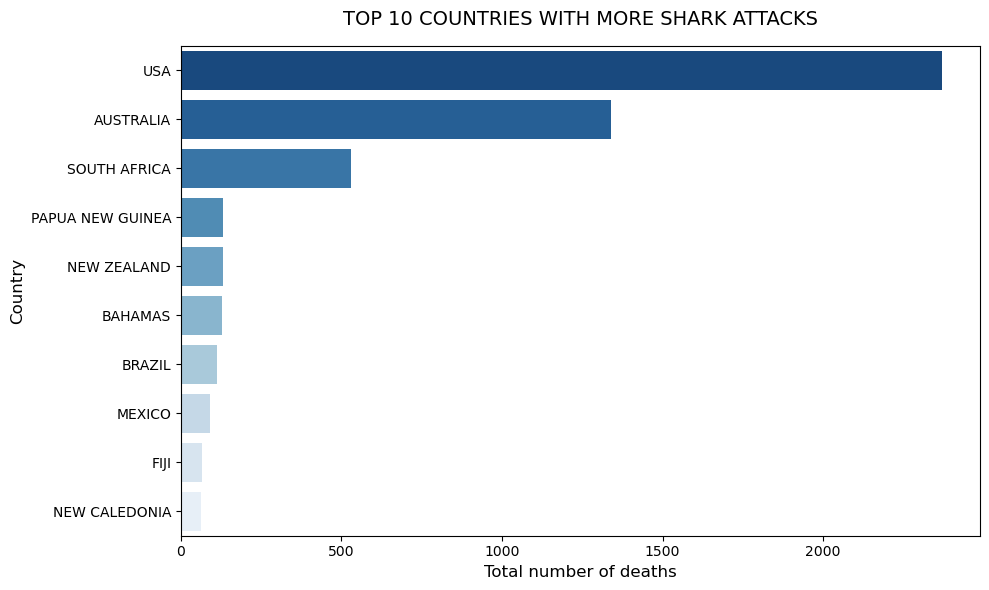

In [92]:
plt.figure(figsize=(10, 6))

top_attacks_country = attacks_by_country.head(10)

sns.barplot(
    x="number of attacks", 
    y='country', 
    data=top_attacks_country, 
    palette='Blues_r' 
)
plt.title('TOP 10 COUNTRIES WITH MORE SHARK ATTACKS', fontsize=14, pad=15)
plt.xlabel('Total number of deaths', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\fotos\AppData\Local\Temp\ipykernel_14948\1755215878.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


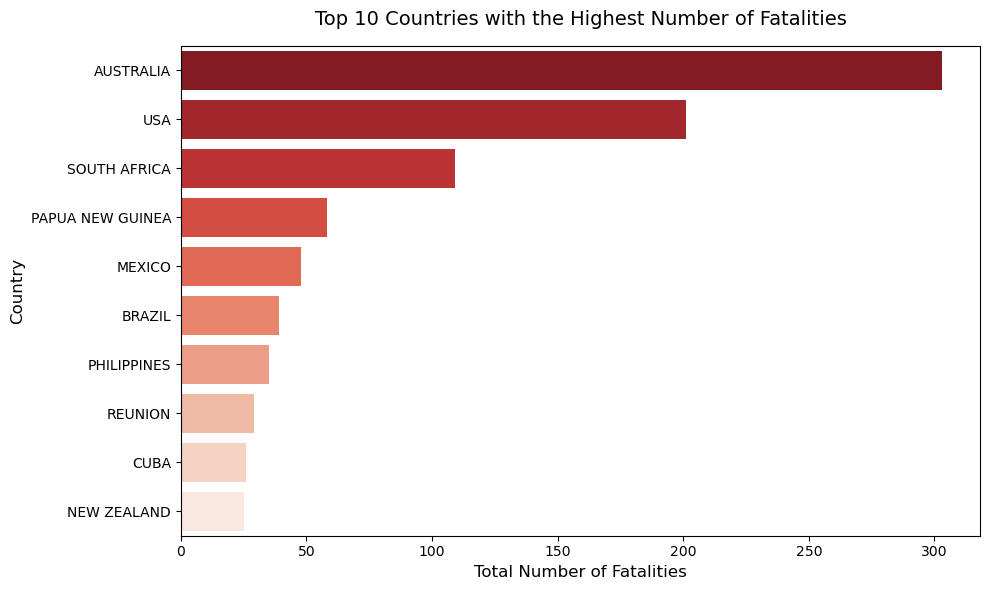

In [94]:
plt.figure(figsize=(10, 6))
top_fatalities_country = deaths_by_country.head(10)

sns.barplot(
    x='number_of_deaths', 
    y='country', 
    data=top_fatalities_country, 
    palette='Reds_r' 
)

plt.title('Top 10 Countries with the Highest Number of Fatalities', fontsize=14, pad=15)
plt.xlabel('Total Number of Fatalities', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

['activity', 'number_of_deaths']


C:\Users\fotos\AppData\Local\Temp\ipykernel_14948\1198931971.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


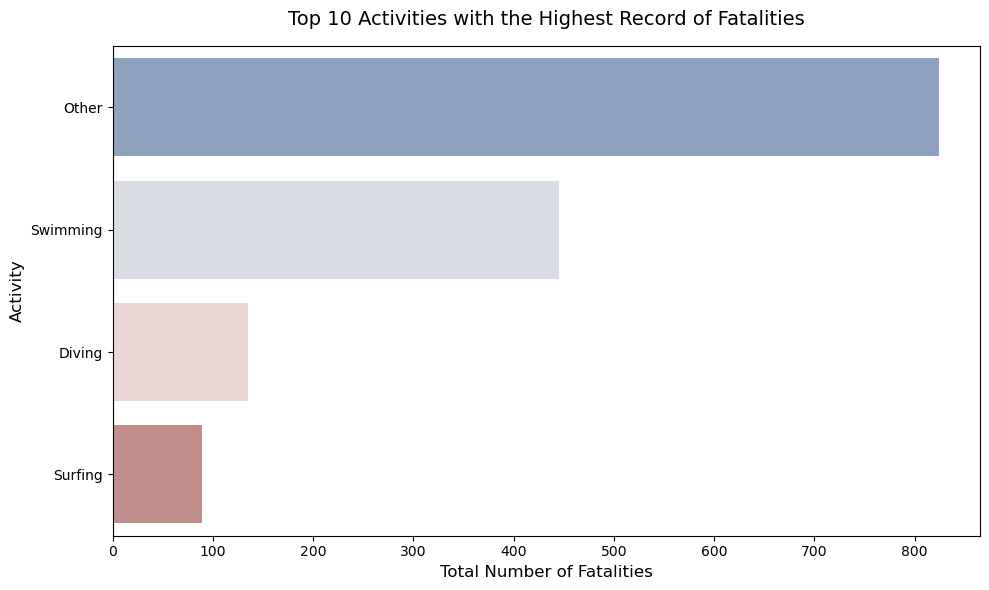

In [98]:
top_fatalities_activity = deaths_by_activity.head(10)

# Now we can safely print the columns
print(top_fatalities_activity.columns.tolist())

plt.figure(figsize=(10, 6))

sns.barplot(
    x='number_of_deaths', 
    y=top_fatalities_activity.columns[0],  
    data=top_fatalities_activity, 
    palette='vlag'  
)

plt.title('Top 10 Activities with the Highest Record of Fatalities', fontsize=14, pad=15)
plt.xlabel('Total Number of Fatalities', fontsize=12)
plt.ylabel('Activity', fontsize=12)
plt.tight_layout()
plt.show()

=== MOST DANGEROUS ACTIVITY BY TOP COUNTRIES ===
             country activity_category  Incident_Count
37               USA             Other            1055
1          AUSTRALIA             Other             677
33      SOUTH AFRICA             Other             269
29  PAPUA NEW GUINEA             Other             101
5            BAHAMAS             Other              99
25       NEW ZEALAND             Other              80
13              FIJI             Other              45
21     NEW CALEDONIA             Other              43
17            MEXICO             Other              41
10            BRAZIL           Surfing              39


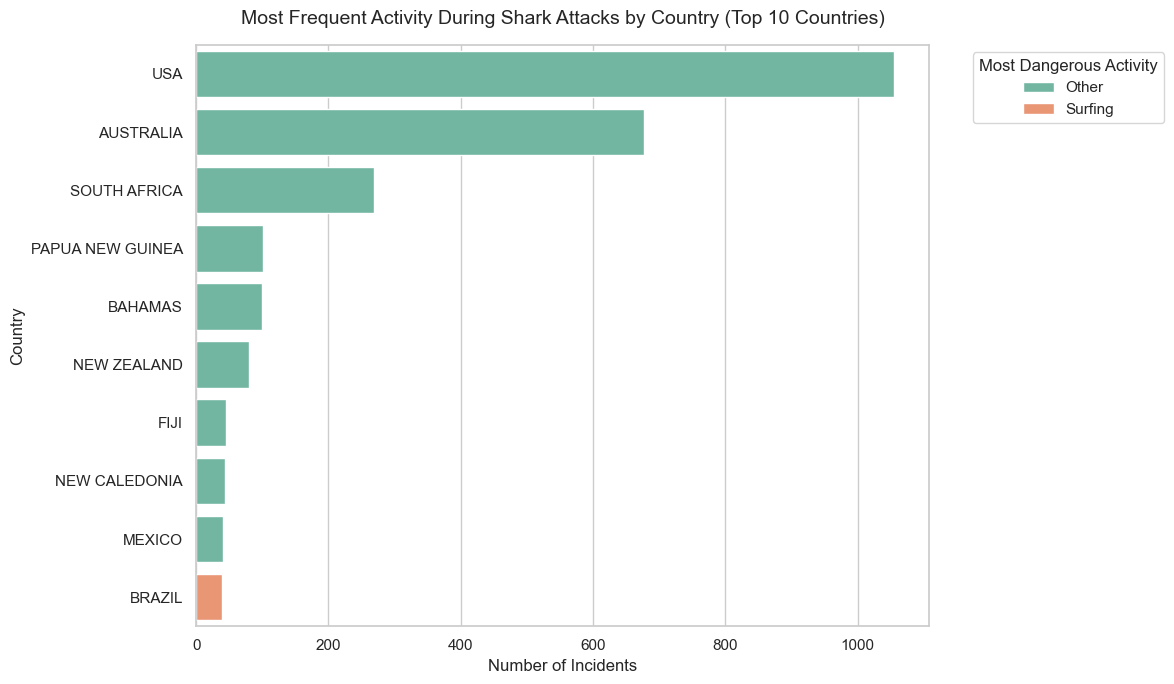

In [99]:

top_10_countries = df1['country'].value_counts().head(10).index


df_top_countries = df1[df1['country'].isin(top_10_countries)]


df_filtered = df_top_countries[df_top_countries['activity_category'].notna() & (df_top_countries['activity'] != '')]
activity_counts = df_filtered.groupby(['country', 'activity_category']).size().reset_index(name='Incident_Count')


most_dangerous_by_country = activity_counts.loc[activity_counts.groupby('country')['Incident_Count'].idxmax()]


most_dangerous_by_country = most_dangerous_by_country.sort_values(by='Incident_Count', ascending=False)

print("=== MOST DANGEROUS ACTIVITY BY TOP COUNTRIES ===")
print(most_dangerous_by_country)


plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")



ax = sns.barplot(
    x='Incident_Count',
    y='country',  
    hue='activity_category', 
    data=most_dangerous_by_country,
    dodge=False,   
    palette='Set2'
)

plt.title('Most Frequent Activity During Shark Attacks by Country (Top 10 Countries)', fontsize=14, pad=15)
plt.xlabel('Number of Incidents', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.legend(title='Most Dangerous Activity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [ ]:
# with the data only considering those activities, this chart is completely useless, but I'll keep it because it took me a long while to have it working and its cute